In [1]:
import pandas as pd

train = pd.read_csv("../data/raw/rossmann/train.csv")
store = pd.read_csv("../data/raw/rossmann/store.csv")

print(train.shape)
print(store.shape)

(1017209, 9)
(1115, 10)


C:\Users\Vedant\AppData\Local\Temp\ipykernel_28196\3898136056.py:3: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/raw/rossmann/train.csv")


In [3]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [ ]:

store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 69.8+ MB


In [6]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


In [7]:
train['Store'].nunique()

1115

In [8]:
train["Date"] = pd.to_datetime(train["Date"])

In [9]:
train.head()    

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [10]:
print(train["Date"].min())
print(train["Date"].max())

2013-01-01 00:00:00
2015-07-31 00:00:00


In [11]:
train.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [12]:
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [13]:
missing = store.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

PromoInterval                544
Promo2SinceYear              544
Promo2SinceWeek              544
CompetitionOpenSinceYear     354
CompetitionOpenSinceMonth    354
CompetitionDistance            3
dtype: int64

In [14]:
df = train.merge(store,on="Store",how="left")

In [15]:
df.shape

(1017209, 18)

In [17]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [18]:
df["Sales"].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

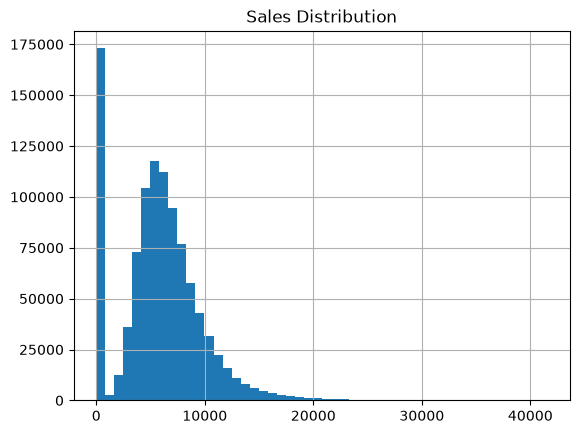

In [19]:
import matplotlib.pyplot as plt

df["Sales"].hist(bins=50)

plt.title("Sales Distribution")
plt.show()

In [20]:
(df["Sales"] == 0).sum()

np.int64(172871)

In [21]:
df[df["Sales"] == 0]["Open"].value_counts()

Open
0    172817
1        54
Name: count, dtype: int64

In [22]:
df[["Sales","Customers"]].corr()

,Sales,Customers
Sales,1.000000,0.894711
Customers,0.894711,1.000000


<Axes: xlabel='Customers', ylabel='Sales'>

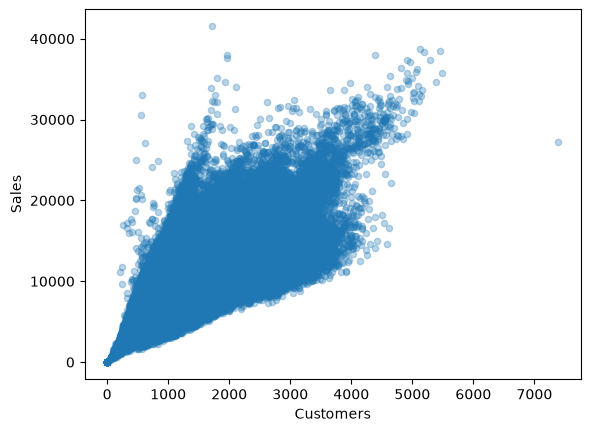

In [23]:
df.plot.scatter(
    x="Customers",
    y="Sales",
    alpha=0.3
)

In [24]:
train["Sales"].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

In [25]:
store["Promo2"].value_counts()

Promo2
1    571
0    544
Name: count, dtype: int64

In [26]:
store[store["Promo2"] == 0][
    ["Promo2","Promo2SinceWeek","Promo2SinceYear","PromoInterval"]
].head()

,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,0,NaN,NaN,NaN
3,0,NaN,NaN,NaN
4,0,NaN,NaN,NaN
5,0,NaN,NaN,NaN
6,0,NaN,NaN,NaN


In [27]:
store[store["CompetitionDistance"].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


In [28]:
store.loc[
    store["Store"].isin([291, 622, 879]),
    ["Store", "StoreType", "Assortment"]
]

,Store,StoreType,Assortment
290,291,d,a
621,622,a,c
878,879,d,a


In [29]:
train["Date"] = pd.to_datetime(train["Date"])

print("Start Date:", train["Date"].min())
print("End Date:", train["Date"].max())

Start Date: 2013-01-01 00:00:00
End Date: 2015-07-31 00:00:00


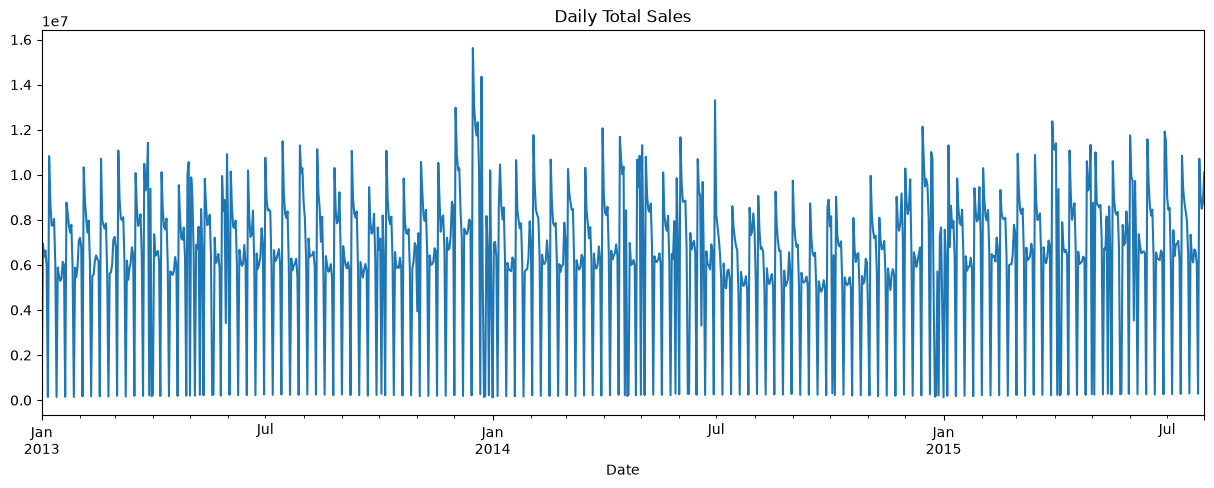

In [30]:
daily_sales = train.groupby("Date")["Sales"].sum()

daily_sales.plot(figsize=(15,5))
plt.title("Daily Total Sales")
plt.show()

In [31]:
train.groupby("DayOfWeek")["Sales"].mean()

DayOfWeek
1    7809.044510
2    7005.244467
3    6555.884138
4    6247.575913
5    6723.274305
6    5847.562599
7     204.183189
Name: Sales, dtype: float64

In [32]:
train.groupby("DayOfWeek")["Open"].mean()

DayOfWeek
1    0.950459
2    0.988309
3    0.974400
4    0.923199
5    0.950598
6    0.995357
7    0.024826
Name: Open, dtype: float64

In [33]:
monthly_sales = train.groupby(
    train["Date"].dt.month
)["Sales"].mean()

monthly_sales

Date
1     5465.395529
2     5645.253150
3     5784.578871
4     5738.866916
5     5489.639973
6     5760.964375
7     6064.915711
8     5693.016554
9     5570.246033
10    5537.037419
11    6008.111821
12    6826.611377
Name: Sales, dtype: float64

In [34]:
yearly_sales = train.groupby(
    train["Date"].dt.year
)["Sales"].mean()

yearly_sales

Date
2013    5658.533675
2014    5833.290704
2015    5878.245380
Name: Sales, dtype: float64

## Time-Based Analysis Summary

### Key Findings

- Dataset covers January 2013 to July 2015 (~31 months).
- Strong weekly seasonality exists.
- Sunday sales are extremely low because ~97.5% of stores are closed.
- Monday records the highest average sales.
- December shows the highest monthly sales, likely due to holiday-season shopping.
- Sales remain relatively stable across years with a slight upward trend.

### Business Implications

- DayOfWeek is expected to be one of the strongest predictive features.
- Month and holiday-related features are likely important.
- Calendar-based feature engineering should significantly improve forecasting performance.

Promotion Analysis
0 = No promotion
1 = Promotion active

In [35]:
train.groupby("Promo")["Sales"].mean()

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64

In [ ]:
# Check how frequently promotions occur
train["Promo"].value_counts(normalize=True) * 100

Promo
0    61.848548
1    38.151452
Name: proportion, dtype: float64

In [ ]:
# Determine average sales for promo vs non-promo days
train.groupby("Promo")["Customers"].mean()

Promo
0    517.823542
1    820.098815
Name: Customers, dtype: float64

1. 4406 / 518 ≈ 8.5

2. 7991 / 820 ≈ 9.7

Avg spend per customer


In [38]:
# Analyze average sales by weekday and promotion status
train.groupby(["DayOfWeek", "Promo"])["Sales"].mean()

DayOfWeek  Promo
1          0        5604.357608
           1        9707.808423
2          0        5612.048396
           1        8227.909603
3          0        5418.548638
           1        7554.021384
4          0        5097.574306
           1        7259.497280
5          0        6178.610459
           1        7202.540577
6          0        5847.562599
7          0         204.183189
Name: Sales, dtype: float64

Promotions substantially increase sales across all weekdays. The strongest promotion effect appears on Mondays, while no promotion records are observed on Saturdays. This may partially explain why Saturday sales are lower than expected despite being part of the weekend.

In [39]:
# Check promotion frequency by weekday
pd.crosstab(train["DayOfWeek"], train["Promo"])

Promo,0,1
DayOfWeek,,
1,66970,77760
2,68084,77580
3,68085,77580
4,68265,77580
5,68265,77580
6,144730,0
7,144730,0


Hypothesis 1

Weekends already attract customers.

No need to spend money on promotions.

Hypothesis 2

Promotions are designed to increase weekday traffic.

Hypothesis 3

This is simply how Rossmann defined the Promo variable in the competition data.

In [41]:
# Compare customer traffic for promo vs non-promo days
train.groupby("Promo")["Customers"].agg(["mean", "median", "max"])

,mean,median,max
Promo,,,
0,517.823542,512.0,5387
1,820.098815,747.0,7388


## Promotion Analysis Summary

### Key Findings

- Promotions have a strong positive relationship with sales.
- Average sales increase from approximately 4,406 to 7,991 when a promotion is active.
- Promotions are associated with significantly higher customer traffic.
- Average customers increase from 518 to 820 during promotional periods.
- Median customers also increase substantially (512 → 747), indicating that the effect is widespread and not driven by a few extreme observations.
- No promotion records were observed on Saturdays or Sundays.

### Business Implications

- Promo is likely one of the most important predictive features for forecasting sales.
- Promotions appear to drive sales primarily by attracting more customers into stores.
- The interaction between Promo and DayOfWeek may be important during feature engineering and modeling.

## Holiday Analysis

0 = No school holiday
1 = School holiday


In [42]:
# Compare average sales during school holidays vs non-school holidays
train.groupby("SchoolHoliday")["Sales"].mean()

SchoolHoliday
0    5620.979034
1    6476.522207
Name: Sales, dtype: float64

In [43]:
# Check frequency of school holiday days
train["SchoolHoliday"].value_counts(normalize=True) * 100

SchoolHoliday
0    82.135333
1    17.864667
Name: proportion, dtype: float64

In [44]:
# Compare average sales across different state holiday types
train.groupby("StateHoliday")["Sales"].mean()

StateHoliday
0    5733.530624
0    5980.279717
a     290.735686
b     214.311510
c     168.733171
Name: Sales, dtype: float64

In [45]:
# Count all StateHoliday categories
train["StateHoliday"].value_counts(dropna=False)

StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [46]:
# Check actual Python types present in StateHoliday
train["StateHoliday"].apply(type).value_counts()

StateHoliday
<class 'str'>    886137
<class 'int'>    131072
Name: count, dtype: int64

In [47]:
# Check store opening rates by holiday type
train.groupby("StateHoliday")["Open"].mean()

StateHoliday
0    0.855560
0    0.855284
a    0.034255
b    0.021674
c    0.017317
Name: Open, dtype: float64

In [48]:
# Compare customer traffic during school holidays
train.groupby("SchoolHoliday")["Customers"].mean()

SchoolHoliday
0    617.645174
1    704.412941
Name: Customers, dtype: float64

## Holiday Analysis Summary

### SchoolHoliday

- Average sales increase from approximately 5,621 to 6,477 during school holidays.
- Average customer count increases from 618 to 704.
- School holidays appear to positively influence sales by increasing customer traffic.
- The effect is noticeable but smaller than the impact of promotions.

### StateHoliday

- State holidays are associated with extremely low sales.
- Average sales fall below 300 during holiday periods.
- Investigation shows that only 1.7–3.4% of stores remain open during state holidays.
- Therefore, the drop in sales is largely explained by store closures.
- StateHoliday is expected to be an important forecasting feature because it strongly affects store operating status.

### Business Implications

- Calendar-based features play a significant role in sales forecasting.
- SchoolHoliday contributes additional demand signals.
- StateHoliday has a strong operational impact due to widespread store closures.
- Holiday-related features should be retained during feature engineering.

## Store Characteristics Analysis

In [49]:
# Compare average sales across store types
df.groupby("StoreType")["Sales"].mean()

StoreType
a     5738.179710
b    10058.837334
c     5723.629246
d     5641.819243
Name: Sales, dtype: float64

In [50]:
# Check how many stores belong to each store type
store["StoreType"].value_counts()

StoreType
a    602
d    348
c    148
b     17
Name: count, dtype: int64

In [51]:
# Compare customer traffic across store types
df.groupby("StoreType")["Customers"].mean()

StoreType
a     659.034880
b    1987.720846
c     673.265894
d     501.434892
Name: Customers, dtype: float64

StoreType B generates substantially higher sales primarily because it attracts significantly more customers. Despite representing only 17 stores, it records nearly three times the customer traffic of other store types, suggesting that it represents a distinct high-volume store format.

In [52]:
# Compare average sales across assortment types
df.groupby("Assortment")["Sales"].mean()

Assortment
a    5481.026096
b    8553.931999
c    6058.676567
Name: Sales, dtype: float64

In [53]:
# Check how many stores belong to each assortment category
store["Assortment"].value_counts()

Assortment
a    593
c    513
b      9
Name: count, dtype: int64

In [54]:
# Compare customer traffic across assortment categories
df.groupby("Assortment")["Customers"].mean()

Assortment
a     619.164636
b    2046.361828
c     624.222733
Name: Customers, dtype: float64

In [55]:
# Compare StoreType and Assortment together
pd.crosstab(
    store["StoreType"],
    store["Assortment"]
)

Assortment,a,b,c
StoreType,,,
a,381,0,221
b,7,9,1
c,77,0,71
d,128,0,220


## Store Characteristics Analysis Summary

### StoreType Analysis

#### Key Findings

- StoreType A, C, and D exhibit relatively similar average sales (~5600–5800).
- StoreType B achieves substantially higher average sales (~10059).
- StoreType B represents only 17 out of 1115 stores (~1.5% of all stores).
- StoreType B also attracts significantly more customers (~1988 customers vs 500–700 for other store types).

#### Business Interpretation

- StoreType appears to influence store performance.
- The exceptional performance of StoreType B is primarily driven by much higher customer traffic.
- Since StoreType B is a very small category, its performance likely reflects a specialized store format rather than a general business trend.

---

### Assortment Analysis

#### Key Findings

- Assortment A: Average sales ≈ 5481
- Assortment B: Average sales ≈ 8554
- Assortment C: Average sales ≈ 6059

- Assortment B stores attract significantly more customers (~2046 customers).
- Only 9 stores belong to Assortment B.

#### Business Interpretation

- Stores with Assortment B exhibit exceptionally high sales and customer traffic.
- However, because the category contains only 9 stores, conclusions should be drawn carefully.

---

### Relationship Between StoreType and Assortment

#### Key Findings

- All Assortment B stores belong to StoreType B.
- StoreTypes A, C, and D are distributed across Assortment A and C.
- Assortment B is exclusive to StoreType B.

#### Business Interpretation

- StoreType and Assortment capture different aspects of a store.
- StoreType describes the store format.
- Assortment describes product variety.
- The unusually strong performance of Assortment B may be influenced by the unique characteristics of StoreType B stores.

## Competition Analysis

In [56]:
# Understand the distribution of competition distance
df["CompetitionDistance"].describe()

count    1.014567e+06
mean     5.430086e+03
std      7.715324e+03
min      2.000000e+01
25%      7.100000e+02
50%      2.330000e+03
75%      6.890000e+03
max      7.586000e+04
Name: CompetitionDistance, dtype: float64

In [57]:
# Compare average competition distance across sales quartiles
pd.qcut(df["CompetitionDistance"], q=4).value_counts().sort_index()

CompetitionDistance
(19.999, 710.0]      255251
(710.0, 2330.0]      254030
(2330.0, 6890.0]     252448
(6890.0, 75860.0]    252838
Name: count, dtype: int64

In [58]:
# Compare average sales across competition distance groups
# Determine whether stores with nearby competitors generate lower sales
df.groupby(
    pd.qcut(df["CompetitionDistance"], q=4)
)["Sales"].mean()

CompetitionDistance
(19.999, 710.0]      6096.122781
(710.0, 2330.0]      5758.126957
(2330.0, 6890.0]     5570.358664
(6890.0, 75860.0]    5680.287231
Name: Sales, dtype: float64

In [60]:
# Compare average customer traffic across competition distance groups
# Determine whether stores with nearby competitors also attract more customers
df.groupby(
    pd.qcut(df["CompetitionDistance"], q=4)
)["Customers"].mean()

CompetitionDistance
(19.999, 710.0]      763.587927
(710.0, 2330.0]      663.377656
(2330.0, 6890.0]     567.493757
(6890.0, 75860.0]    538.471484
Name: Customers, dtype: float64

In [ ]:
# Compare sales for stores with and without competition distance information
# Check whether stores with missing competition data have unusual sales behavior
df.groupby(
    df["CompetitionDistance"].isna()
)["Sales"].mean()

CompetitionDistance
False    5777.042614
True     4535.892884
Name: Sales, dtype: float64

## Competition Analysis Summary

### Competition Distance Distribution

- Competition distances range from 20 meters to approximately 75.9 kilometers.
- The distribution is highly skewed, with a median distance of 2.33 km and a mean distance of 5.43 km.
- Some stores face extremely nearby competitors, while others operate with very distant competition.

### Competition Distance vs Sales

- Stores with the nearest competitors surprisingly exhibit the highest average sales.
- Average sales decrease as competition distance increases, although the relationship is not perfectly monotonic.

### Competition Distance vs Customers

- Stores with nearby competitors attract significantly more customers.
- Average customer traffic decreases steadily as competition distance increases.
- This suggests that stores with nearby competitors are often located in high-traffic commercial areas.

### Business Interpretation

- CompetitionDistance does not appear to have a simple "more competition = lower sales" relationship.
- Nearby competitors may act as a proxy for attractive business locations with higher customer demand.
- CompetitionDistance is likely capturing both competitive pressure and location attractiveness.

### Missing Competition Information

- Only 3 stores have missing competition information.
- These stores exhibit lower average sales, but the sample size is too small for reliable conclusions.

## CUSTOMER ANALYSIS

In [62]:
# Calculate average revenue generated per customer
(train["Sales"] / train["Customers"]).describe()

count    844340.000000
mean          9.493619
std           2.197494
min           0.000000
25%           7.895563
50%           9.250000
75%          10.899729
max          64.957854
dtype: float64

This suggests:

Sales variability is driven more by customer volume than by dramatic changes in spending per customer.

In [63]:
# Check how many rows have zero customers
(train["Customers"] == 0).sum()

np.int64(172869)

Customers = 0
→ 172,869 rows
Sales = 0
→ 172,871 rows

Customers = 0
↓
Sales = 0
↓
Store Closed

In [64]:
# Compare average sales when customer count is greater than zero
train.loc[
    train["Customers"] > 0,
    "Sales"
].corr(
    train.loc[
        train["Customers"] > 0,
        "Customers"
    ]
)

np.float64(0.8235533723704869)

## Customer Analysis Summary

### Relationship Between Customers and Sales

#### Key Findings

- Sales and Customers exhibit a very strong positive correlation.
- Overall correlation:

    - Sales vs Customers = 0.895

- After removing zero-customer days:

    - Sales vs Customers = 0.824

- The relationship remains extremely strong even when closed-store days are excluded.

#### Revenue Per Customer

- Average revenue per customer ≈ 9.5
- Median revenue per customer ≈ 9.25
- Most customers generate similar levels of revenue.
- Sales variability appears to be driven more by customer volume than by large differences in spending per customer.

#### Zero-Customer Days

- 172,869 rows contain zero customers.
- This closely matches the number of zero-sales observations.
- These records primarily correspond to store closures.

#### Business Interpretation

- Customer traffic is one of the strongest drivers of sales.
- Many factors investigated earlier (promotions, holidays, store type, competition) appear to influence sales by influencing customer traffic.
- Customer forecasting may be a viable intermediate modeling step before sales forecasting.

# Overall Business Insights

## Major Drivers of Sales

### 1. Store Opening Status

- Store closures explain the vast majority of zero-sales days.
- Nearly all zero-sales observations correspond to stores being closed.
- Open status is a fundamental driver of sales.

---

### 2. Weekly Seasonality

- Strong weekly patterns exist.
- Sunday sales are extremely low because approximately 97.5% of stores remain closed.
- Monday records the highest average sales.
- DayOfWeek is expected to be one of the strongest predictive features.

---

### 3. Promotions

- Promotions have a substantial impact on sales.
- Average sales increase from approximately 4,406 to 7,991 during promotional periods.
- Promotions significantly increase customer traffic.
- Promo is likely one of the most important forecasting features.

---

### 4. Holidays

#### School Holidays

- School holidays are associated with increased customer traffic and higher sales.
- The effect is moderate but meaningful.

#### State Holidays

- State holidays are associated with dramatic sales reductions.
- Most stores remain closed during state holidays.
- StateHoliday strongly influences store operations and sales.

---

### 5. Customer Traffic

- Customer count exhibits an extremely strong relationship with sales.
- Correlation between Sales and Customers remains above 0.82 even after removing closed-store days.
- Many business factors appear to influence sales indirectly through customer traffic.

---

### 6. Store Characteristics

#### StoreType

- StoreType influences customer traffic and sales performance.
- StoreType B stores generate substantially higher sales but represent only a small number of stores.

#### Assortment

- Product assortment influences store performance.
- Assortment B stores exhibit exceptionally high sales but belong to a very small specialized group.

---

### 7. Competition

- CompetitionDistance does not exhibit a simple negative relationship with sales.
- Stores with nearby competitors often generate higher sales and customer traffic.
- CompetitionDistance likely captures both competitive pressure and location attractiveness.

---

## Implications for Modeling

The analysis suggests that sales are primarily influenced by:

1. Open Status
2. DayOfWeek
3. Promotions
4. Customer Traffic
5. State Holidays
6. School Holidays
7. Store Characteristics
8. Competition Characteristics

Feature engineering should focus on extracting temporal patterns, promotional effects, competition-related information, and historical sales behavior through lag and rolling-window features.